In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go up one level so 'blocks' is visible
import warnings
warnings.filterwarnings('ignore')


=== Step 1: DAG Visualization ===


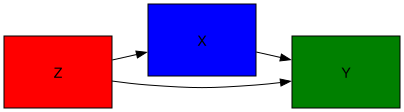

'digraph{Z->X; Z->Y; X->Y;}'

In [2]:
# ======= Playground: See Everything Working =======
from blocks.sample_dags import sample_dag
from blocks.draw import draw_duplo_dag_inline, duplo_to_dot
from blocks.simulate import simulate_data
from blocks.regression import regression
from blocks.dowhy import dowhy_help
from dowhy import CausalModel

# ===== Step 1: DAG Visualization =====
nodes = sample_dag()
print("\n=== Step 1: DAG Visualization ===")
draw_duplo_dag_inline(nodes)

duplo_to_dot(nodes)

In [3]:
# ===== Simulate Data =====
print("\n=== Step 2: Simulate Data ===")
df = simulate_data(nodes, n=1000)
print(df.head())


=== Step 2: Simulate Data ===
          Z         X         Y
0 -1.385093 -1.008436 -2.585200
1 -0.878827 -0.539409 -1.338702
2  0.060056 -0.117880  1.134978
3 -1.218386  0.269966 -1.363282
4 -0.029182 -1.319308 -0.728843


In [4]:
# Create the causal model:

model = CausalModel(
    data=df,
    treatment="X",  # You specify which column 
    outcome="Y",    # You specify which column
    graph=duplo_to_dot(nodes)  # Convert your nodes to DOT
)

In [5]:
dowhy_help('workflow')

=== DoWhy Workflow ===

1️⃣ CREATE MODEL:
model = CausalModel(data=df, treatment='X', outcome='Y', graph='...')

2️⃣ IDENTIFY EFFECT:
estimand = model.identify_effect()
# Shows all available identification strategies

3️⃣ ESTIMATE EFFECT:
effect = model.estimate_effect(estimand, method_name='...')
# Choose method based on your data type and assumptions

4️⃣ VALIDATE RESULTS:
refutation = model.refute_estimate(estimand, effect, method_name='...')
# Test robustness of your findings


In [6]:
# ===== Step 2: Understand the estimand =====
estimand = model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d          
────(E[Y|Z])
d[X]        
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,Z,U) = P(Y|X,Z)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
 d          
────(E[Y|Z])
d[X]        
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,Z,U) = P(Y|X,Z)



In [7]:
dowhy_help('methods')

=== DoWhy Estimation Methods for help estimating the effect in the model ===

📊 BACKDOOR METHODS:
• backdoor.linear_regression
  - Works with: Continuous or binary treatment
  - Best for: Linear relationships, continuous outcomes

• backdoor.propensity_score_matching
  - Works with: Binary treatment ONLY
  - Best for: Non-linear relationships, matching similar units

• backdoor.propensity_score_weighting
  - Works with: Binary treatment ONLY
  - Best for: Reweighting to balance treatment groups

• backdoor.propensity_score_stratification
  - Works with: Binary treatment ONLY
  - Best for: Subclassification analysis

🎯 INSTRUMENTAL VARIABLE METHODS:
• iv.instrumental_variable
  - Works with: Continuous or binary treatment
  - Requires: Valid instruments in your DAG
  - Best for: When unobserved confounding suspected

🚪 OTHER METHODS:
• frontdoor.two_stage_regression
  - Requires: Valid mediator variables
  - Rarely applicable in practice


In [12]:
estimate = model.estimate_effect(estimand, method_name='backdoor.linear_regression')
print(effect)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d          
────(E[Y|Z])
d[X]        
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,Z,U) = P(Y|X,Z)

## Realized estimand
b: Y~X+Z
Target units: ate

## Estimate
Mean value: 1.0410605252228637



In [13]:
dowhy_help('tests')

=== DoWhy Refutation Tests ===

🔍 ROBUSTNESS TESTS:
• random_common_cause
  - Adds random confounder to test sensitivity - change should be close to 0
refutation3 = model.refute_estimate(identified_estimand, estimate, method_name='data_subset_refuter')

• placebo_treatment_refuter
  - Replaces treatment with random variable - placebo effect should be close to 0
refutation2 = model.refute_estimate(identified_estimand, estimate, method_name='placebo_treatment_refuter')

• data_subset_refuter
  - Tests on random subsets of data - change should be close to 0

• add_unobserved_common_cause
  - Simulates unobserved confounding - change should be close to 0
refutation1 = model.refute_estimate(identified_estimand, estimate, method_name='random_common_cause')

🎯 USAGE:
refutation = model.refute_estimate(estimand, effect, method_name='test_name')


In [20]:
refutation1 = model.refute_estimate(estimand, estimate, method_name='random_common_cause')
print(refutation1)

Refute: Add a random common cause
Estimated effect:1.0410605252228637
New effect:1.040930409887398
p value:0.96



In [17]:
refutation2 = model.refute_estimate(estimand, estimate, method_name='placebo_treatment_refuter')
print(refutation2)

Refute: Use a Placebo Treatment
Estimated effect:1.0410605252228637
New effect:0.0
p value:1.0



In [18]:
refutation3 = model.refute_estimate(estimand, estimate, method_name='data_subset_refuter')
print(refutation3)

Refute: Use a subset of data
Estimated effect:1.0410605252228637
New effect:1.0396696016896043
p value:0.9

